In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [2]:
# 2. Load Dataset
file_path = '/content/Total.csv'  # Replace with your file path

try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully!\n")
except FileNotFoundError:
    print(f"File not found at {file_path}")
    exit()


Data loaded successfully!



In [3]:
# 3. Data Cleaning
print("--- 3. Data Cleaning ---")
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Fill or drop missing values
df['BasePay'] = pd.to_numeric(df['BasePay'], errors='coerce')
df['OvertimePay'] = pd.to_numeric(df['OvertimePay'], errors='coerce')
df['OtherPay'] = pd.to_numeric(df['OtherPay'], errors='coerce')
df['Benefits'] = pd.to_numeric(df['Benefits'], errors='coerce')
df['TotalPay'] = pd.to_numeric(df['TotalPay'], errors='coerce')
df['TotalPayBenefits'] = pd.to_numeric(df['TotalPayBenefits'], errors='coerce')

# Drop rows where TotalPayBenefits is NaN
df.dropna(subset=['TotalPayBenefits'], inplace=True)

# Handle negative or zero pay values (optional: remove unrealistic records)
df = df[df['TotalPayBenefits'] >= 0]

print(f"\nData shape after cleaning: {df.shape}")
print(df.head())

--- 3. Data Cleaning ---
Missing values per column:
EmployeeName        0
JobTitle            0
BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
Year                0
dtype: int64

Data shape after cleaning: (312872, 9)
        EmployeeName                                        JobTitle  \
0     NATHANIEL FORD  GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY   
1       GARY JIMENEZ                 CAPTAIN III (POLICE DEPARTMENT)   
2     ALBERT PARDINI                 CAPTAIN III (POLICE DEPARTMENT)   
3  CHRISTOPHER CHONG            WIRE ROPE CABLE MAINTENANCE MECHANIC   
4    PATRICK GARDNER    DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)   

     BasePay  OvertimePay   OtherPay  Benefits   TotalPay  TotalPayBenefits  \
0  167411.18         0.00  400184.25       NaN  567595.43         567595.43   
1  155966.02    245131.88  137811.38       NaN  538909.28         538909.28   
2  212739.13    106088.18  


--- 4. Exploratory Data Analysis (EDA) ---

Descriptive statistics for numeric columns:
             BasePay    OvertimePay       OtherPay       Benefits  \
count  312269.000000  312871.000000  312871.000000  276712.000000   
mean    69809.824813    5669.110583    3460.807822   25017.835014   
std     45376.230503   12745.818701    7387.354135   15088.576058   
min      -166.010000    -292.800000   -7058.590000  -13939.420000   
25%     35728.060000       0.000000       0.000000   12733.522500   
50%     67712.680000       0.000000     728.000000   28327.655000   
75%     99315.020000    5223.535000    3958.680000   35268.565000   
max    592394.340000  309481.030000  400184.250000  125891.730000   

            TotalPay  TotalPayBenefits  
count  312872.000000     312872.000000  
mean    78805.169162     100931.582399  
std     53229.737859      66483.774598  
min         0.000000          0.000000  
25%     38807.362500      48965.367500  
50%     74910.325000     100012.610000  
75

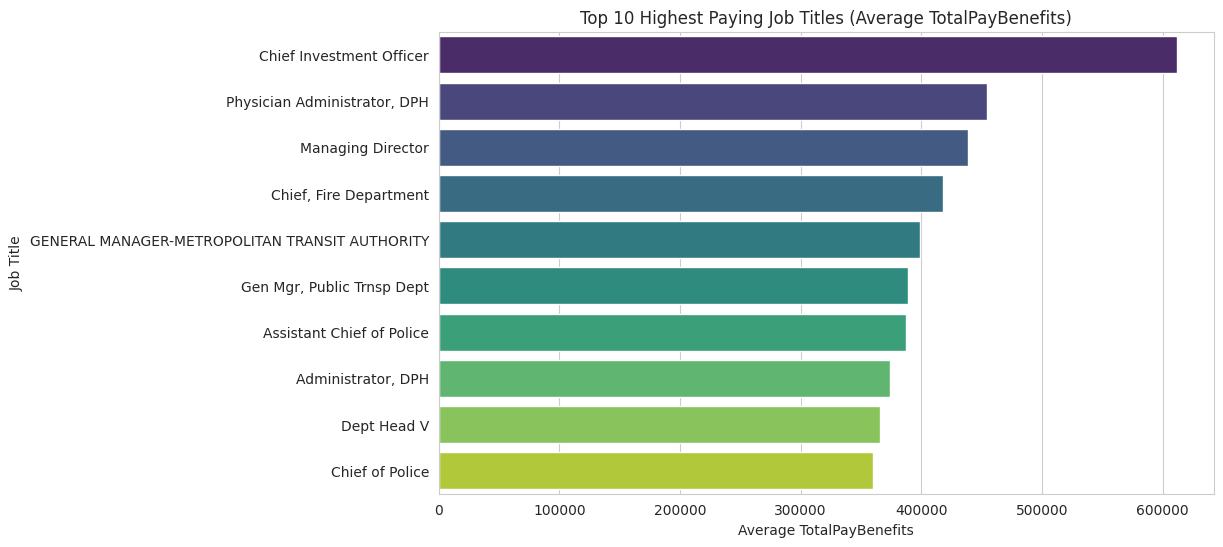

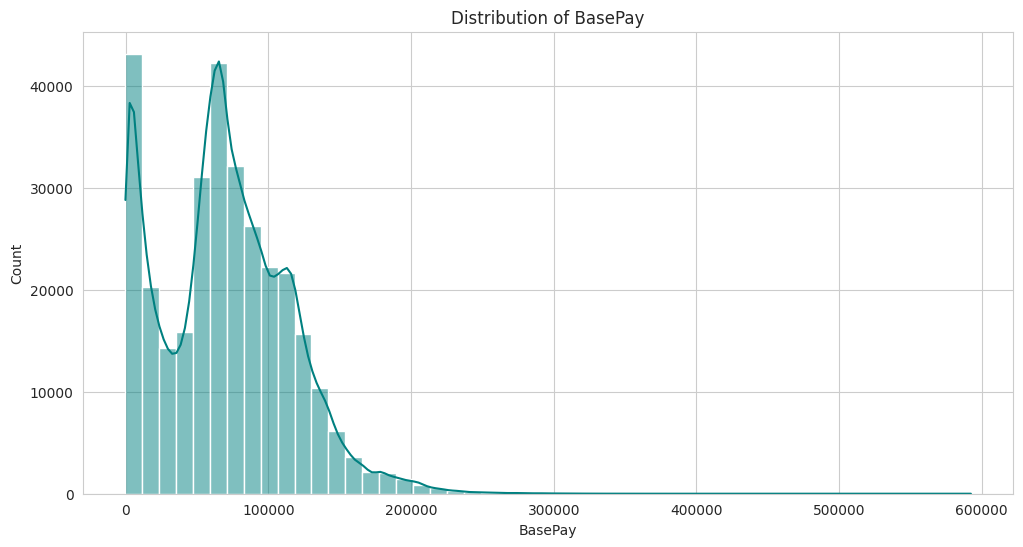

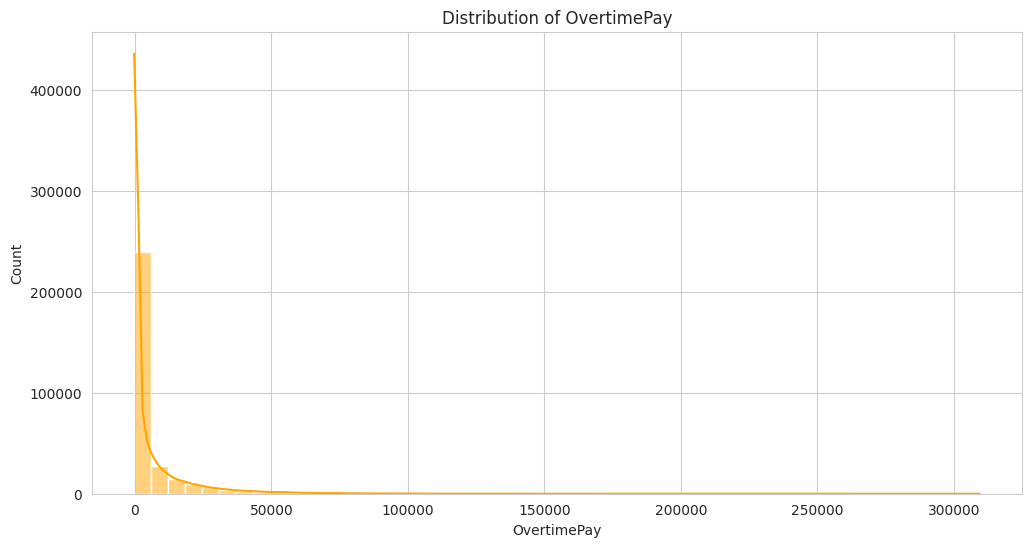

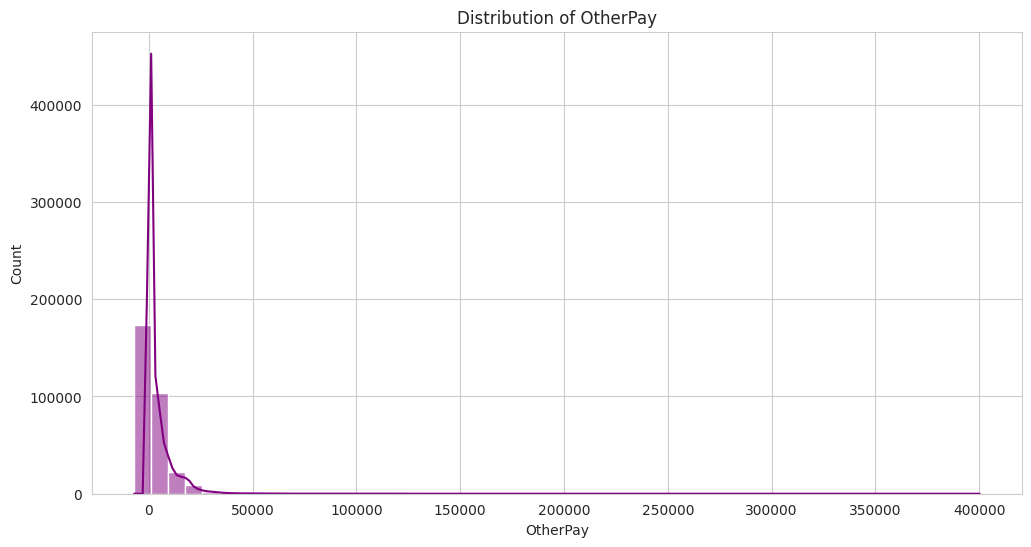

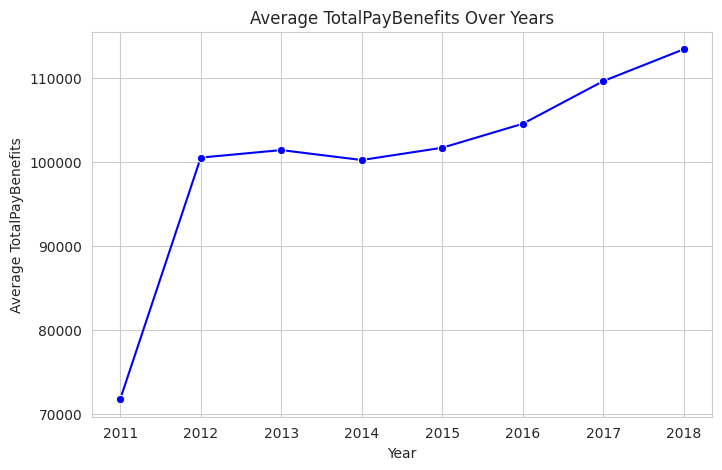

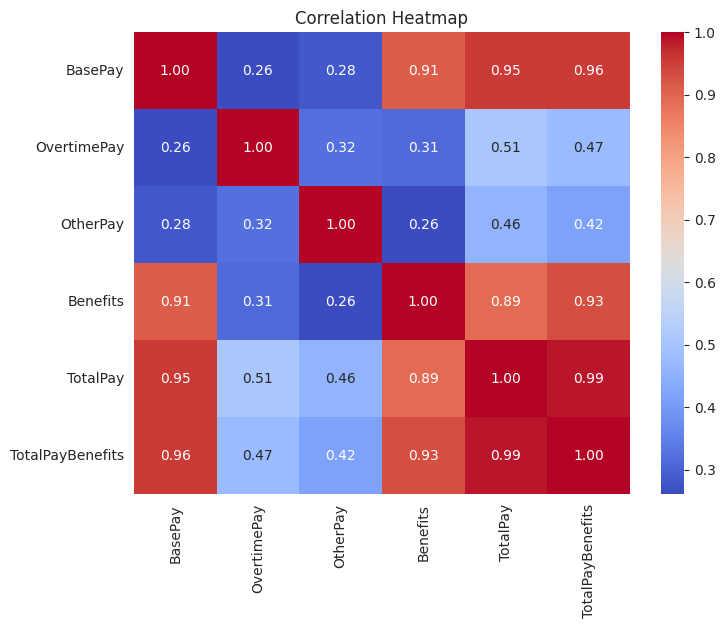

In [4]:
# 4. Exploratory Data Analysis (EDA)
print("\n--- 4. Exploratory Data Analysis (EDA) ---")

# 4.1 Descriptive Statistics
print("\nDescriptive statistics for numeric columns:")
print(df[['BasePay','OvertimePay','OtherPay','Benefits','TotalPay','TotalPayBenefits']].describe())

# 4.2 Top 10 Highest Paying Job Titles
top_jobs = df.groupby('JobTitle')['TotalPayBenefits'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(y=top_jobs.index, x=top_jobs.values, palette='viridis')
plt.title("Top 10 Highest Paying Job Titles (Average TotalPayBenefits)")
plt.xlabel("Average TotalPayBenefits")
plt.ylabel("Job Title")
plt.show()

# 4.3 Distribution of BasePay, OvertimePay, OtherPay
plt.figure(figsize=(12,6))
sns.histplot(df['BasePay'], bins=50, color='teal', kde=True)
plt.title("Distribution of BasePay")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(df['OvertimePay'], bins=50, color='orange', kde=True)
plt.title("Distribution of OvertimePay")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(df['OtherPay'], bins=50, color='purple', kde=True)
plt.title("Distribution of OtherPay")
plt.show()

# 4.4 Pay Over the Years
pay_by_year = df.groupby('Year')['TotalPayBenefits'].mean()
plt.figure(figsize=(8,5))
sns.lineplot(x=pay_by_year.index, y=pay_by_year.values, marker='o', color='blue')
plt.title("Average TotalPayBenefits Over Years")
plt.xlabel("Year")
plt.ylabel("Average TotalPayBenefits")
plt.show()

# 4.5 Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['BasePay','OvertimePay','OtherPay','Benefits','TotalPay','TotalPayBenefits']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [6]:
# 5. Salary Prediction with Machine Learning
print("\n--- 5. Salary Prediction (Linear Regression) ---")

# Select features and target
X = df[['BasePay', 'OvertimePay', 'OtherPay', 'Benefits', 'JobTitle']]
y = df['TotalPayBenefits']

# Handle categorical variable JobTitle using OneHotEncoder and numerical features using StandardScaler and SimpleImputer
from sklearn.impute import SimpleImputer

categorical_features = ['JobTitle']
numerical_features = ['BasePay', 'OvertimePay', 'OtherPay', 'Benefits']

# Create transformers for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing numerical values with the mean
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- 5. Salary Prediction (Linear Regression) ---
Mean Absolute Error (MAE): 541.39
R-squared (R2) Score: 0.9979


In [7]:
# ===================== 6. Conclusion =====================
print("\n--- 6. Conclusion ---")
print("1. Key Insights from EDA:")
print("   - Average base pay is highly correlated with total compensation.")
print("   - Job titles like CEO or Department Heads have highest salaries.")
print("   - Benefits contribute significantly to total pay.")

print("\n2. Model Performance:")
print(f"   - Linear Regression MAE: {mae:.2f}")
print(f"   - Linear Regression R2 Score: {r2:.4f}")
print("The model reasonably predicts employee total compensation based on base pay, overtime, other pay, benefits, and job title.")


--- 6. Conclusion ---
1. Key Insights from EDA:
   - Average base pay is highly correlated with total compensation.
   - Job titles like CEO or Department Heads have highest salaries.
   - Benefits contribute significantly to total pay.

2. Model Performance:
   - Linear Regression MAE: 541.39
   - Linear Regression R2 Score: 0.9979
The model reasonably predicts employee total compensation based on base pay, overtime, other pay, benefits, and job title.
